In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme()
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [10, 6]


warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("student-mat.csv")

In [3]:
print("Data Shape: ", df.shape)
print("Data Info: ")
df.info()

print("Missing Values: ")
print(df.isnull().sum())

print("Numerical Statistics: ")
print(df.describe())

Data Shape:  (395, 33)
Data Info: 
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   school                    395 non-null    str  
 1   sex                       395 non-null    str  
 2   age                       395 non-null    int64
 3   address                   395 non-null    str  
 4   famsize                   395 non-null    str  
 5   Parrent_status            395 non-null    str  
 6   Mother_edu                395 non-null    int64
 7   Father_edu                395 non-null    int64
 8   Mother_job                395 non-null    str  
 9   Father_job                395 non-null    str  
 10  reason_to_chose_school    395 non-null    str  
 11  guardian                  395 non-null    str  
 12  traveltime                395 non-null    int64
 13  weekly_studytime          395 non-null    int64
 14  failures          

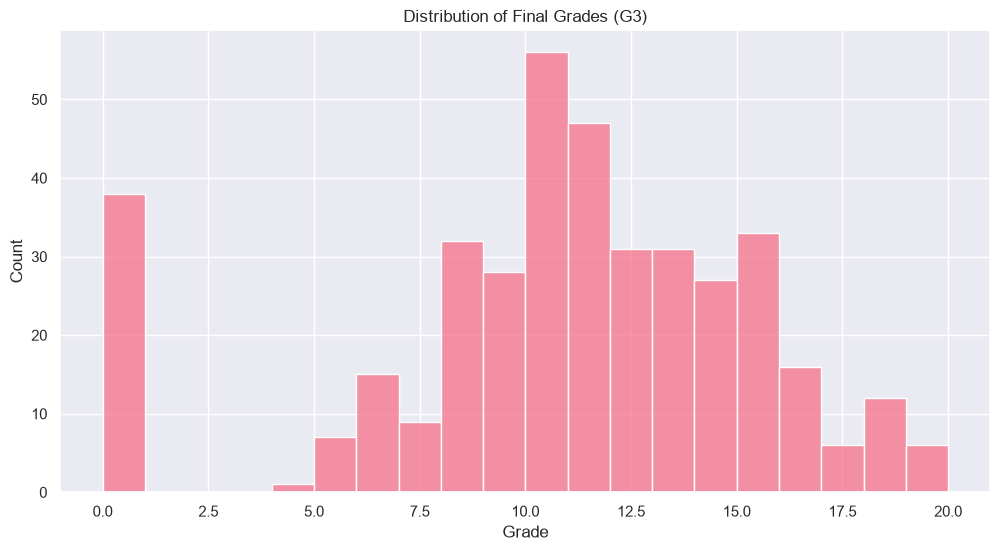

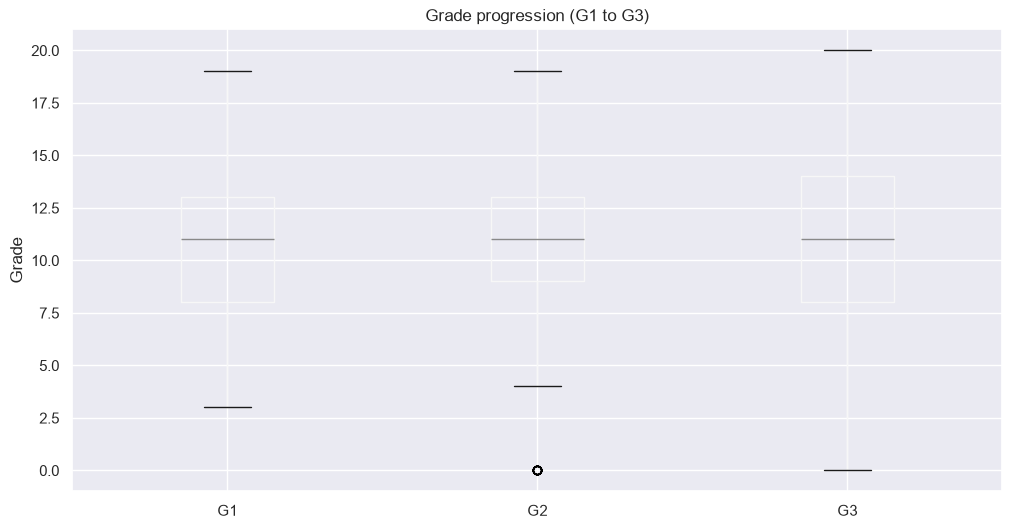

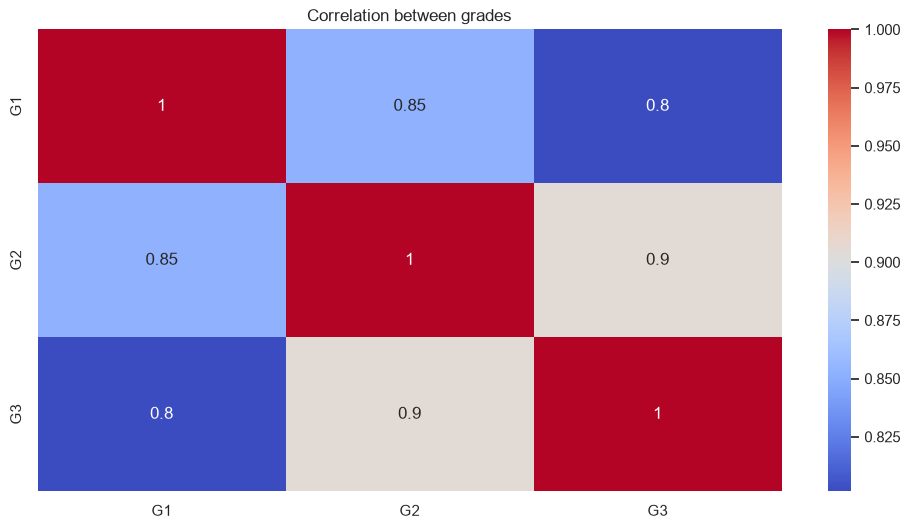

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="G3", bins=20)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12, 6))
df[["G1", "G2", "G3"]].boxplot()
plt.title("Grade progression (G1 to G3)")
plt.ylabel("Grade")
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(df[["G1", "G2", "G3"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between grades")
plt.show()


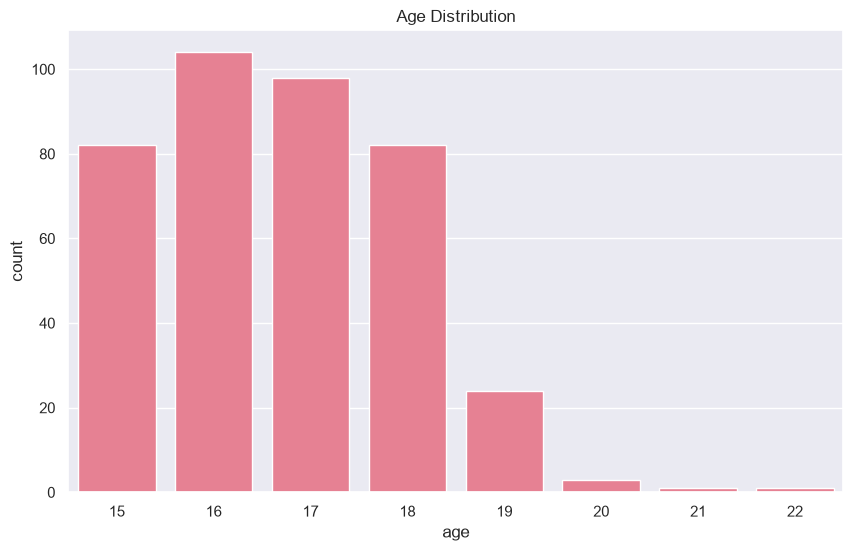

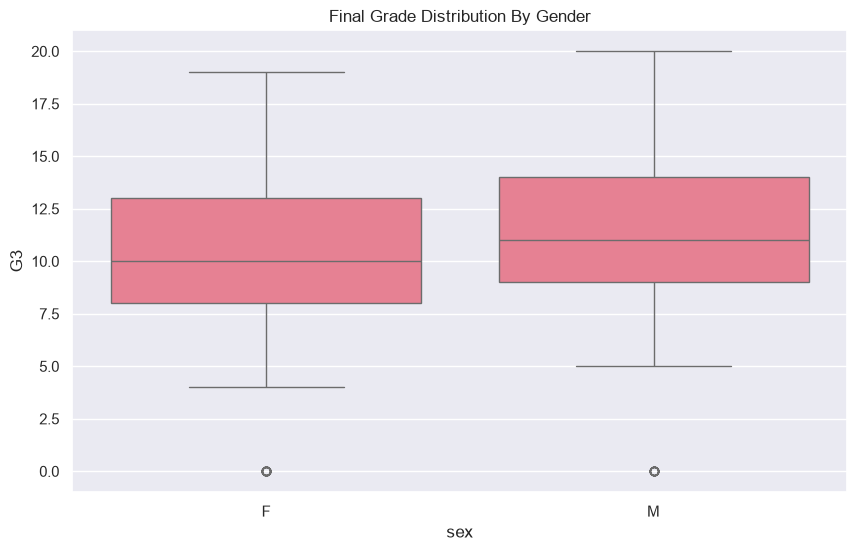

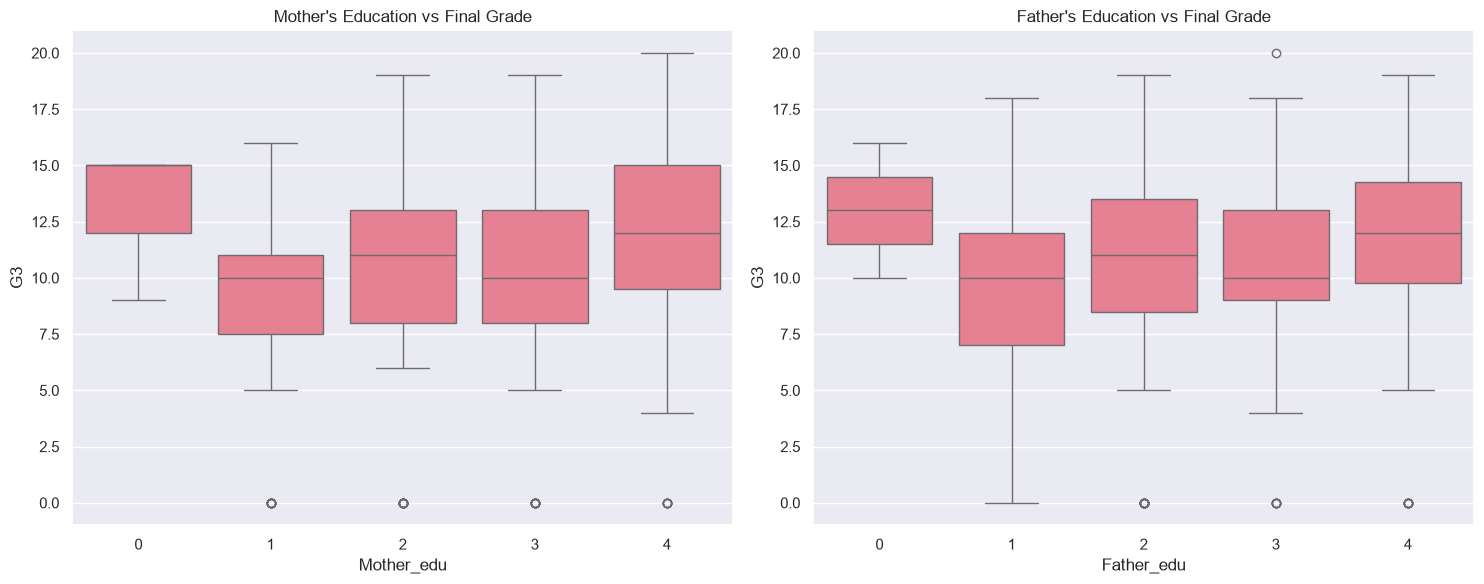

In [5]:
# Demographic analysis

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="age")
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="sex", y="G3")
plt.title("Final Grade Distribution By Gender")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=df, x="Mother_edu", y="G3", ax=ax1)
ax1.set_title("Mother's Education vs Final Grade")
sns.boxplot(data=df, x="Father_edu", y="G3", ax=ax2)
ax2.set_title("Father's Education vs Final Grade")
plt.tight_layout()
plt.show()

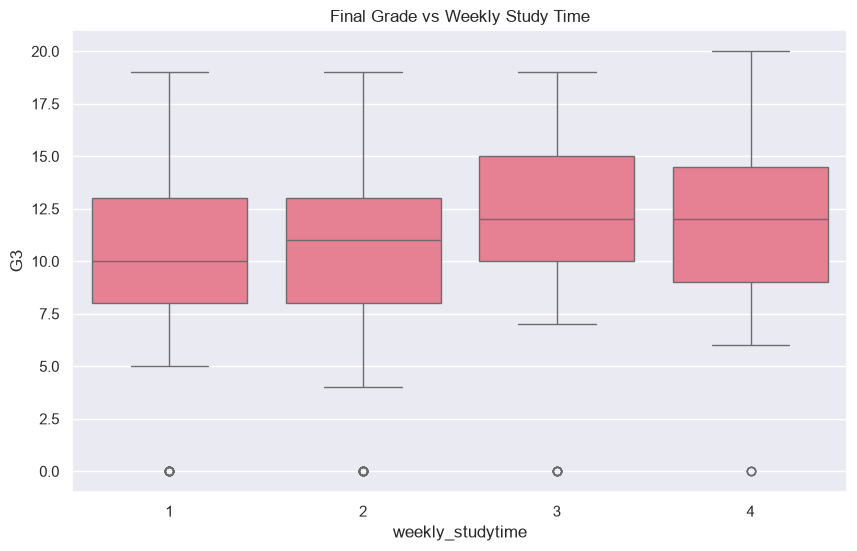

<Figure size 1200x500 with 0 Axes>

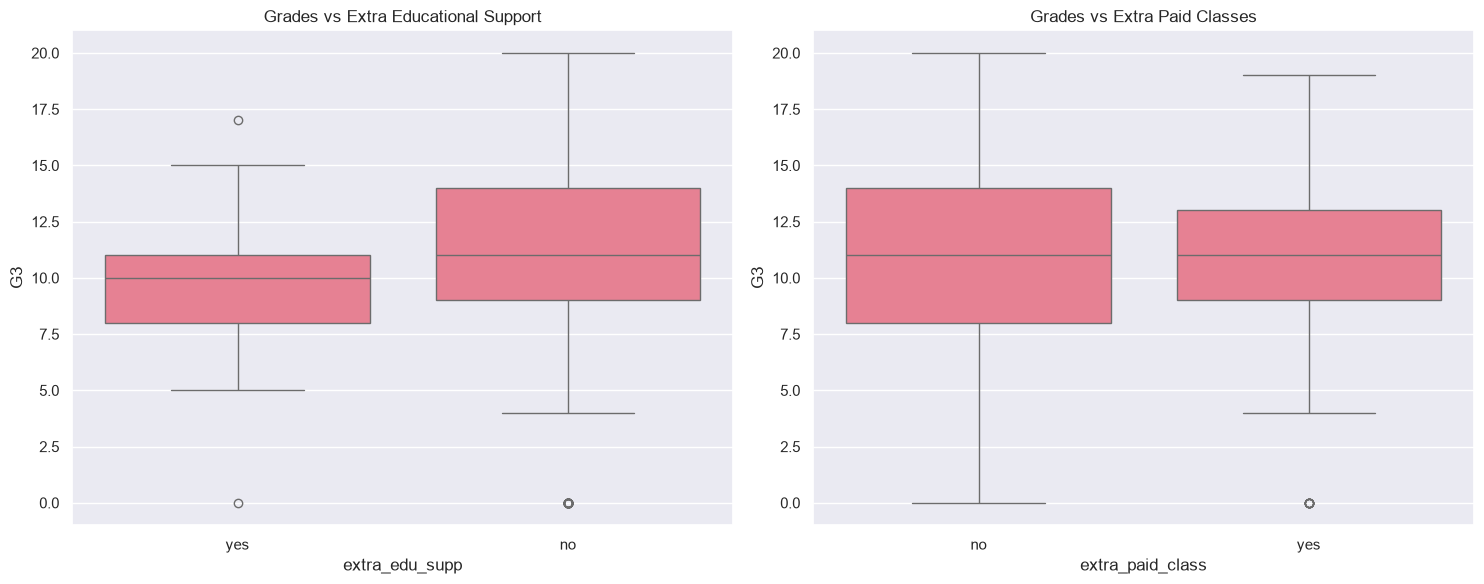

In [6]:
#study habits analysis

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="weekly_studytime", y="G3")
plt.title("Final Grade vs Weekly Study Time")
plt.show()

# extra educational support
plt.figure(figsize=(12, 5))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=df, x="extra_edu_supp", y="G3", ax=ax1)
ax1.set_title("Grades vs Extra Educational Support")
sns.boxplot(data=df, x="extra_paid_class", y="G3", ax=ax2)
ax2.set_title("Grades vs Extra Paid Classes")
plt.tight_layout()
plt.show()

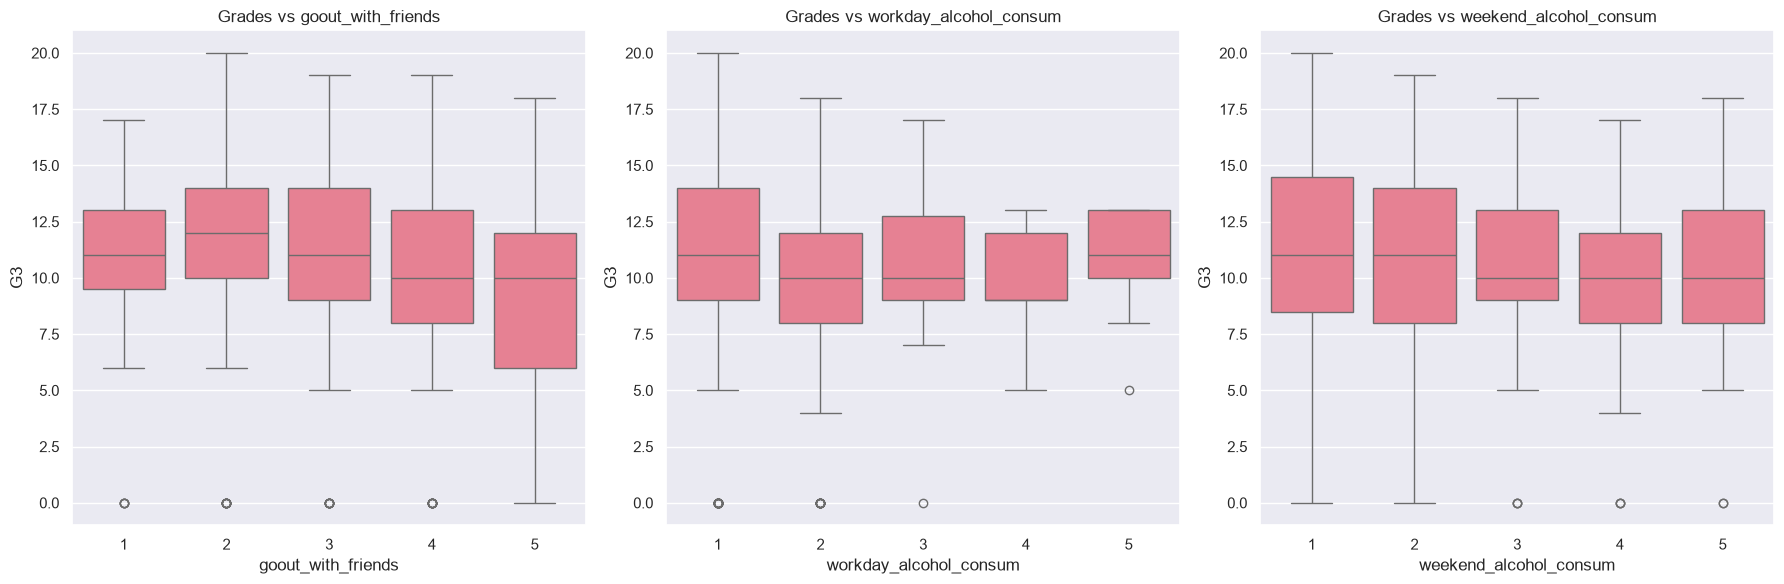

In [7]:
social_factors = ["goout_with_friends", "workday_alcohol_consum", "weekend_alcohol_consum"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, factor in enumerate(social_factors):
    sns.boxplot(data=df, x=factor, y="G3", ax=axes[i])
    axes[i].set_title(f"Grades vs {factor}")

plt.tight_layout()
plt.show()

In [8]:
X = df.drop(["G1", "G2", "G3"], axis=1)
y = df["G3"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [50, 100, 200],      # number of boosting stages
    'model__learning_rate': [0.01, 0.05, 0.1],  # step size shrinkage
    'model__max_depth': [3, 4, 5],              # maximum depth
    'model__min_samples_leaf': [1, 3, 5]        # minimum samples required to be at a leaf node
}

print("Starting Grid Search...")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Starting Grid Search...



--- Model Performance ---
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 3, 'model__n_estimators': 50}
R² Score: 0.1858
RMSE:     4.0861
MAE:      3.3257


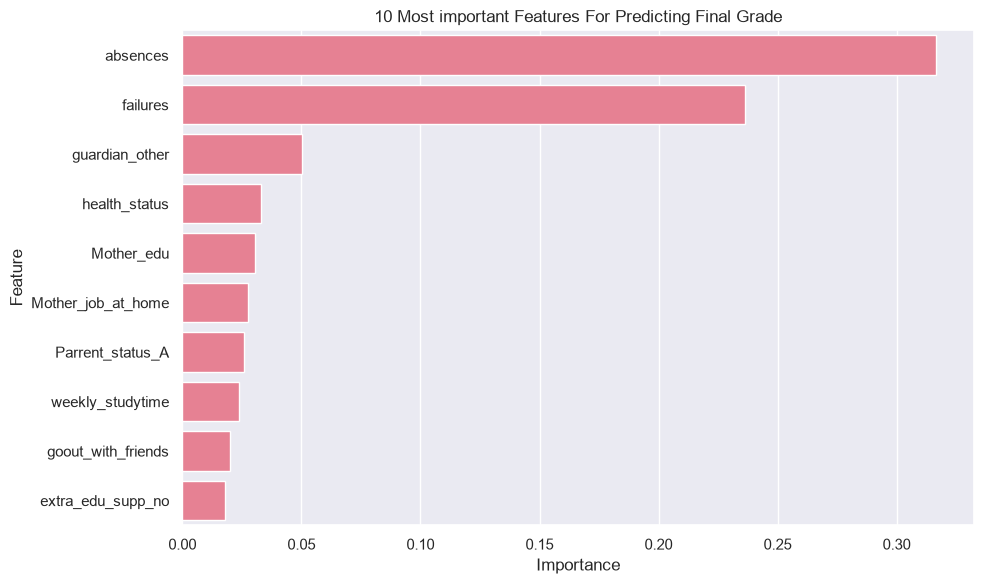

In [10]:

print("\n--- Model Performance ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.4f}")

cat_encoder = best_model.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([cat_feature_names, numerical_cols])

importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
plt.title("10 Most important Features For Predicting Final Grade")
plt.tight_layout()
plt.show()

In [12]:
def predict_student_grade(model, student_dictionary):
    student_df = pd.DataFrame([student_dictionary])
    prediction = model.predict(student_df)
    
    return prediction[0]

In [ ]:
new_student = {
    'school': 'GP',                     # Gabriel Pereira
    'sex': 'F',                         # Female
    'age': 16,                          
    'address': 'U',                     # Urban
    'famsize': 'GT3',                   # Greater than 3
    'Parrent_status': 'T',              # Living together
    'Mother_edu': 4,                    # Higher education
    'Father_edu': 4,                    # Higher education
    'Mother_job': 'teacher',            
    'Father_job': 'health',             
    'reason_to_chose_school': 'reputation', 
    'guardian': 'mother',               
    'traveltime': 1,                    # <15 min
    'weekly_studytime': 4,              # >10 hours
    'failures': 0,                      
    'extra_edu_supp': 'yes',            
    'family_edu_supp': 'yes',           
    'extra_paid_class': 'yes',          
    'extra_curr_activities': 'no',      
    'nursery': 'yes',                   
    'Interested_in_higher_edu': 'yes',  
    'internet_access': 'yes',           
    'romantic_relationship': 'no',      
    'Family_quality_reln': 5,           # Excellent
    'freetime_after_school': 3,         # Moderate
    'goout_with_friends': 2,            # Rarely
    'workday_alcohol_consum': 1,        # Very low
    'weekend_alcohol_consum': 1,        # Very low
    'health_status': 5,                 # Very good
    'absences': 2                       # Low absences
}

predicted_grade = predict_student_grade(best_model, new_student)
print(f"Predicted Final Grade (G3): {predicted_grade:.2f} out of 20")

Predicted Final Grade (G3): 11.05 out of 20
